<a href="https://colab.research.google.com/github/pras1978/fitness-journey-analyzer/blob/main/notebooks/02_exercise_recognition_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import libraries

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

Define dataset path

In [5]:
BASE_PATH = "/content/drive/MyDrive/fitness-journey-analyzer/data"

cv_path = os.path.join(BASE_PATH, "cv/workout_images")

print(os.listdir(cv_path))

['barbell biceps curl', 'bench press', 'chest fly machine', 'deadlift', 'decline bench press', 'hammer curl', 'hip thrust', 'incline bench press', 'lat pulldown', 'lateral raises', 'leg extension', 'leg raises', 'plank', 'pull up', 'push up', 'romanian deadlift', 'russian twist', 'shoulder press', 'squat', 't bar row', 'tricep dips', 'tricep pushdown']


Image preprocessing

In [6]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

Load training dataset


In [7]:
train_data = datagen.flow_from_directory(
    cv_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 11090 images belonging to 22 classes.


Load validation dataset

In [8]:
val_data = datagen.flow_from_directory(
    cv_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 2763 images belonging to 22 classes.


Load MobileNetV2 model

In [9]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
for layer in base_model.layers:
    layer.trainable = False

Build classification head

In [11]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

predictions = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

Compile model

In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,424,790 (9.25 MB)

 Trainable params: 166,806 (651.59 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Train model

In [13]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 3171s 9s/step - accuracy: 0.6743 - loss: 1.2335 - val_accuracy: 0.6866 - val_loss: 1.0400
Epoch 2/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 63s 181ms/step - accuracy: 0.9782 - loss: 0.1023 - val_accuracy: 0.7343 - val_loss: 0.9973
Epoch 3/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 62s 180ms/step - accuracy: 0.9953 - loss: 0.0354 - val_accuracy: 0.7503 - val_loss: 0.8533
Epoch 4/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 63s 181ms/step - accuracy: 0.9977 - loss: 0.0183 - val_accuracy: 0.7365 - val_loss: 0.9811
Epoch 5/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 63s 181ms/step - accuracy: 0.9993 - loss: 0.0091 - val_accuracy: 0.7463 - val_loss: 1.0398
Epoch 6/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 64s 185ms/step - accuracy: 0.9998 - loss: 0.0047 - val_accuracy: 0.7369 - val_loss: 1.1653
Epoch 7/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 63s 182ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 0.7134 - val_loss: 1.3540
Epoch 8/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 63s 180ms/step - accuracy: 0.9986 - loss: 0.

Plot training results

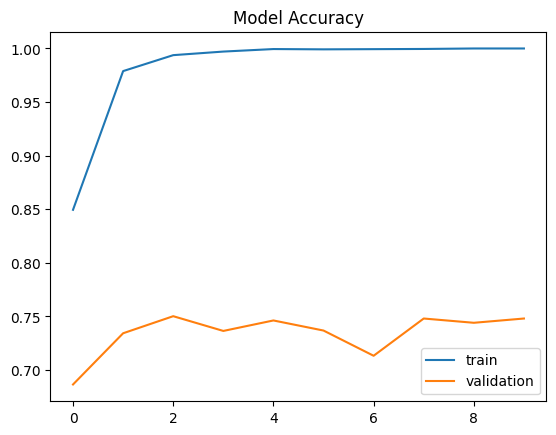

In [14]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')

plt.legend()
plt.title("Model Accuracy")
plt.show()

Save trained model

In [15]:
MODEL_PATH = "/content/drive/MyDrive/fitness-journey-analyzer/models/exercise_model.h5"

model.save(MODEL_PATH)

print("Model saved!")

Model saved!


Test prediction

In [16]:
from tensorflow.keras.preprocessing import image

img_path = train_data.filepaths[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
[[9.9703634e-01 2.8463425e-09 4.3428039e-07 8.3741630e-10 2.8074032e-09
  1.7954466e-03 2.9898848e-09 4.6124845e-07 7.9852639e-04 3.5992212e-04
  4.8078633e-12 8.5056842e-09 1.0005376e-08 8.0088745e-09 2.5755709e-08
  7.8911020e-09 4.9641367e-11 3.0306135e-10 4.5684465e-06 4.3995201e-06
  1.4839445e-09 1.5407739e-08]]
